# 📊 Kompleksowa Analiza EDA i Segmentacja Rynku E-Commerce (Olist)


## 1. Cel i Zakres Projektu
Projekt przedstawia proces end-to-end analizy eksploracyjnej (EDA) brazylijskiego rynku e-commerce na podstawie rzeczywistych, anonimowych danych platformy **Olist** (ok. 100 tys. zamówień z lat 2016–2018).

### 🗺️ Schemat Relacji Bazy Danych (ERD)
Poniższy diagram przedstawia architekturę połączeń i klucze relacyjne pomiędzy tabelami w silniku DuckDB. Pomaga on zrozumieć strukturę bazy przed przystąpieniem do budowania zapytań SQL:

```mermaid
erDiagram
    CUSTOMERS {
        varchar customer_id PK
        varchar customer_unique_id
    }
    ORDERS {
        varchar order_id PK
        varchar customer_id FK
        varchar order_status
    }
    ORDER_ITEMS {
        varchar order_id FK
        int order_item_id
        varchar product_id FK
        varchar seller_id FK
        float price
    }
    ORDER_PAYMENTS {
        varchar order_id FK
        int payment_sequential
        varchar payment_type
    }
    ORDER_REVIEWS {
        varchar review_id PK
        varchar order_id FK
        int review_score
    }
    PRODUCTS {
        varchar product_id PK
        varchar product_category_name
    }
    SELLERS {
        varchar seller_id PK
    }
    TRANSLATION {
        varchar product_category_name PK
        varchar product_category_name_english
    }

    CUSTOMERS ||--o{ ORDERS : "customer_id -> customer_id"
    ORDERS ||--|{ ORDER_ITEMS : "order_id -> order_id"
    ORDERS ||--o{ ORDER_PAYMENTS : "order_id -> order_id"
    ORDERS ||--o{ ORDER_REVIEWS : "order_id -> order_id"
    ORDER_ITEMS }|--|| PRODUCTS : "product_id -> product_id"
    ORDER_ITEMS }|--|| SELLERS : "seller_id -> seller_id"
    PRODUCTS }|--o| TRANSLATION : "product_category_name -> product_category_name"
```

## 🛠️ Podejście Technologiczne
W projekcie wykorzystano nowoczesny stos technologiczny: **Python** jako środowisko uruchomieniowe oraz **DuckDB** jako osadzony, wysoce wydajny silnik SQL działający w pamięci (In-Memory). Wszystkie transformacje, czyszczenie oraz agregacje danych zostały wykonane za pomocą **czystego SQL**, co pozwala na błyskawiczne przetwarzanie dużych zbiorów danych bez nadmiernego obciążania pamięci RAM przez tradycyjne biblioteki.

## Krok 1 & 2: Konfiguracja Środowiska, Rejestracja Danych i Testy Integralności
W tej sekcji inicjalizujemy bazę danych oraz mapujemy pliki CSV bezpośrednio jako widoki w DuckDB. Stosujemy regułę **DRY (Don't Repeat Yourself)** przy użyciu pętli słownika. Przeprowadzamy również testy jakości danych (unikalność kluczy głównych oraz brak rekordów osieroconych).

In [7]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Wyciszenie ostrzeżeń bibliotek dla czystości prezentacji w portfolio
warnings.filterwarnings('ignore')

# Konfiguracja jednolitego i nowoczesnego stylu wykresów
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Inicjalizacja osadzonej bazy DuckDB w pamięci (In-Memory Database)
con = duckdb.connect(database=':memory:')

# Definicja mapowania plików źródłowych
tables = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "translation": "product_category_name_translation.csv"
}

# Dynamiczne tworzenie wirtualnych widoków SQL bezpośrednio na plikach CSV
for table_name, csv_file in tables.items():
    con.execute(f"CREATE OR REPLACE VIEW {table_name} AS SELECT * FROM read_csv_auto('{csv_file}')")

print("✓ Sukces: Wszystkie pliki CSV zostały pomyślnie podpięte jako widoki SQL.")

print("\n--- 1. WOLUMEN DANYCH W TABELACH ---")
for table in tables.keys():
    count = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"Tabela '{table}': {count:,} wierszy")

print("\n--- 2. WERYFIKACJA UNIKALNOŚCI KLUCZA GŁÓWNEGO (orders) ---")
pk_check = con.execute("""
SELECT 
    COUNT(order_id) as total_rows,
    COUNT(DISTINCT order_id) as unique_keys,
    (COUNT(order_id) - COUNT(DISTINCT order_id)) as duplicate_count
FROM orders
""").df()
print(pk_check)

print("\n--- 3. TEST INTEGRALNOŚCI REFERENCYJNEJ (Orders -> Customers) ---")
orphans = con.execute("""
SELECT COUNT(o.order_id) FROM orders o
LEFT JOIN customers c ON o.customer_id = c.customer_id
WHERE c.customer_id IS NULL
""").fetchone()[0]
print(f"Liczba zamówień bez przypisanego klienta (sierot): {orphans}")

✓ Sukces: Wszystkie pliki CSV zostały pomyślnie podpięte jako widoki SQL.

--- 1. WOLUMEN DANYCH W TABELACH ---
Tabela 'customers': 99,441 wierszy
Tabela 'geolocation': 1,000,163 wierszy
Tabela 'order_items': 112,650 wierszy
Tabela 'order_payments': 103,886 wierszy
Tabela 'order_reviews': 99,224 wierszy
Tabela 'orders': 99,441 wierszy
Tabela 'products': 32,951 wierszy
Tabela 'sellers': 3,095 wierszy
Tabela 'translation': 71 wierszy

--- 2. WERYFIKACJA UNIKALNOŚCI KLUCZA GŁÓWNEGO (orders) ---
   total_rows  unique_keys  duplicate_count
0       99441        99441                0

--- 3. TEST INTEGRALNOŚCI REFERENCYJNEJ (Orders -> Customers) ---
Liczba zamówień bez przypisanego klienta (sierot): 0


## Krok 3: Czyszczenie Danych i Zaawansowany Feature Engineering
W tym kroku budujemy warstwę danych oczyszczonych (`v_cleaned_*`). Wykorzystujemy rzutowanie typów (`::TIMESTAMP`), mapujemy portugalskie nazwy kategorii na język angielski za pomocą zapytań relacyjnych oraz stosujemy funkcję `COALESCE`, aby bezpiecznie obsłużyć wartości `NULL`. Dodatkowo wprowadzamy dedykowane metryki biznesowe (czas dostawy, flaga opóźnienia).

In [8]:
print("Uruchamianie procesów transformacji danych i budowania widoków analitycznych...")

# 1. Czyszczenie i translacja słownika produktów
con.execute("""
CREATE OR REPLACE VIEW v_cleaned_products AS
SELECT 
    p.product_id,
    COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') AS product_category,
    COALESCE(p.product_name_lenght, 0) AS product_name_length,
    COALESCE(p.product_description_lenght, 0) AS product_description_length,
    COALESCE(p.product_photos_qty, 0) AS product_photos_qty,
    p.product_weight_g,
    p.product_length_cm,
    p.product_height_cm,
    p.product_width_cm
FROM products p
LEFT JOIN translation t ON p.product_category_name = t.product_category_name;
""")

# 2. Parsowanie dat, wyliczanie KPI logistycznych oraz obsługa błędu estymacji
con.execute("""
CREATE OR REPLACE VIEW v_cleaned_orders AS
SELECT 
    order_id,
    customer_id,
    order_status,
    order_purchase_timestamp::TIMESTAMP AS purchase_time,
    order_approved_at::TIMESTAMP AS approved_time,
    order_delivered_carrier_date::TIMESTAMP AS carrier_time,
    order_delivered_customer_date::TIMESTAMP AS delivered_to_customer_time,
    order_estimated_delivery_date::TIMESTAMP AS estimated_delivery_time,
    
    -- Rzeczywisty czas dostawy w dniach
    DATE_PART('day', order_delivered_customer_date::TIMESTAMP - order_purchase_timestamp::TIMESTAMP) AS actual_delivery_days,
    -- Planowany czas dostawy w dniach
    DATE_PART('day', order_estimated_delivery_date::TIMESTAMP - order_purchase_timestamp::TIMESTAMP) AS estimated_delivery_days,
    
    -- Wyznaczenie binarnej flagi opóźnienia dostawy (1 = opóźnione, 0 = na czas)
    CASE 
        WHEN order_delivered_customer_date::TIMESTAMP > order_estimated_delivery_date::TIMESTAMP THEN 1
        WHEN order_delivered_customer_date IS NULL AND order_estimated_delivery_date::TIMESTAMP < CURRENT_DATE THEN 1
        ELSE 0 
    END AS is_delayed,
    
    -- Odchylenie od estymacji (wartości dodatnie oznaczają spóźnienie)
    DATE_PART('day', order_delivered_customer_date::TIMESTAMP - order_estimated_delivery_date::TIMESTAMP) AS delivery_diff_days
FROM orders;
""")

print("✓ Sukces: Widoki transformacyjne zostały poprawnie utworzone w bazie danych.")

print("\n--- ANALIZA ZALEŻNOŚCI BRAKU DATY DOSTAWY OD STATUSU ZAMÓWIENIA ---")
null_analysis = con.execute("""
SELECT 
    order_status,
    COUNT(*) AS total_orders,
    COUNT(CASE WHEN delivered_to_customer_time IS NULL THEN 1 END) AS missing_delivery_date
FROM v_cleaned_orders
GROUP BY order_status
ORDER BY total_orders DESC;
""").df()
print(null_analysis)

Uruchamianie procesów transformacji danych i budowania widoków analitycznych...
✓ Sukces: Widoki transformacyjne zostały poprawnie utworzone w bazie danych.

--- ANALIZA ZALEŻNOŚCI BRAKU DATY DOSTAWY OD STATUSU ZAMÓWIENIA ---
  order_status  total_orders  missing_delivery_date
0    delivered         96478                      8
1      shipped          1107                   1107
2     canceled           625                    619
3  unavailable           609                    609
4     invoiced           314                    314
5   processing           301                    301
6      created             5                      5
7     approved             2                      2


## Krok 4: Analiza Właściwa (EDA) – Hipotezy Biznesowe i Wizualizacje
Przechodzimy do testowania kluczowych hipotez biznesowych. Łączymy wyniki zaawansowanych agregacji SQL bezpośrednio z bibliotekami wizualizacyjnymi (`Seaborn` i `Matplotlib`).

### Hipoteza 1: Trend Przychodów i Wolumenu Zamówień w Czasie
Badamy stabilność wzrostu platformy i identyfikujemy piki sprzedażowe (sezonowość, m.in. Black Friday).

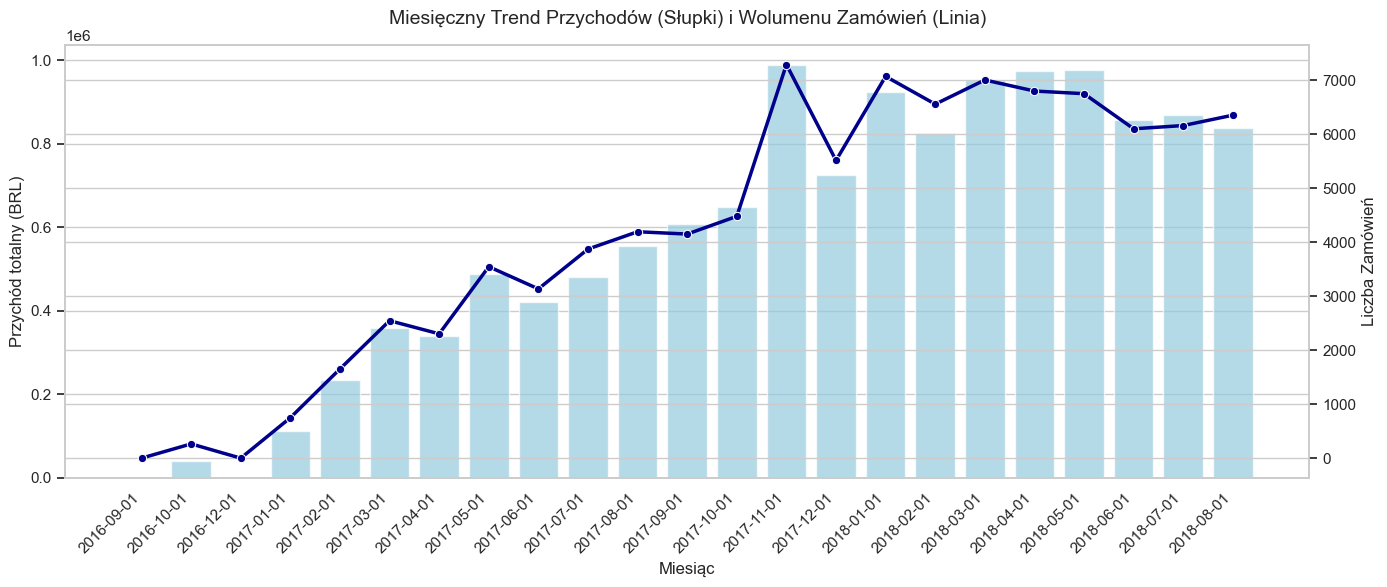

In [9]:
df_revenue = con.execute("""
SELECT 
    DATE_TRUNC('month', o.purchase_time)::DATE AS month,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(i.price), 2) AS total_revenue
FROM v_cleaned_orders o
JOIN order_items i ON o.order_id = i.order_id
WHERE o.order_status = 'delivered' AND o.purchase_time < '2018-09-01'
GROUP BY 1 ORDER BY 1;
""").df()

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=df_revenue, x='month', y='total_revenue', color='skyblue', ax=ax1, alpha=0.7)
ax1.set_title('Miesięczny Trend Przychodów (Słupki) i Wolumenu Zamówień (Linia)', pad=15)
ax1.set_xlabel('Miesiąc')
ax1.set_ylabel('Przychód totalny (BRL)')
ax1.set_xticklabels(df_revenue['month'].astype(str), rotation=45, ha='right')

ax2 = ax1.twinx()
sns.lineplot(data=df_revenue, x=range(len(df_revenue)), y='total_orders', color='darkblue', marker='o', ax=ax2, linewidth=2.5)
ax2.set_ylabel('Liczba Zamówień')

plt.tight_layout()
plt.show()

### Hipoteza 2: Analiza Logistyczna i Wąskie Gardła w Dostawach
Weryfikujemy, które stany w Brazylii charakteryzują się najwyższym współczynnikiem opóźnień przesyłek w stosunku do deklarowanej daty estymowanej.

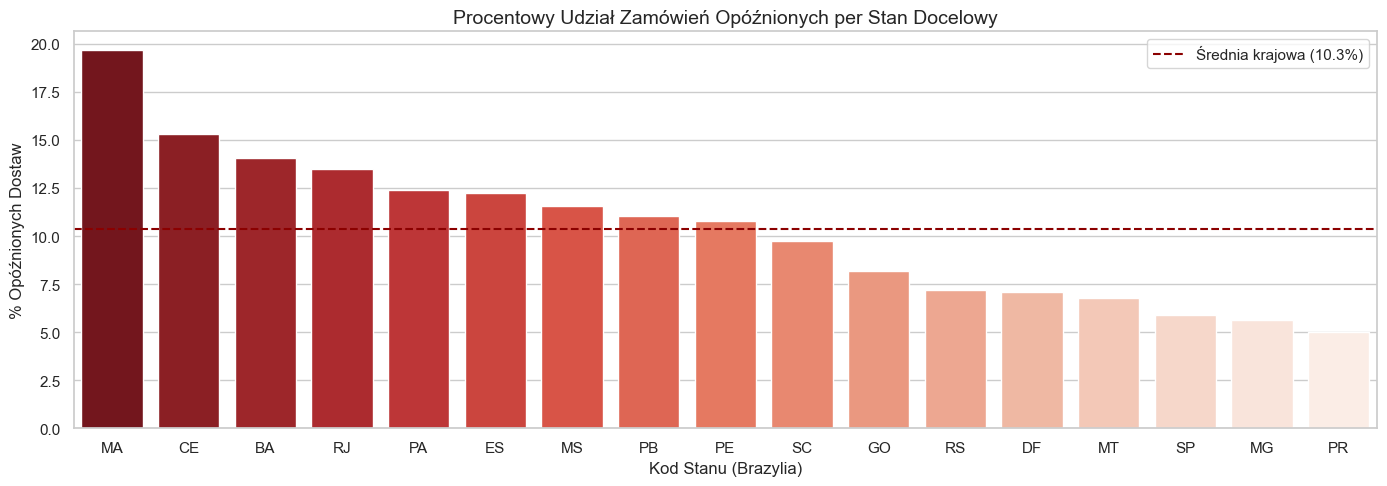

In [10]:
df_logistic = con.execute("""
SELECT 
    c.customer_state,
    COUNT(*) AS total_orders,
    ROUND(AVG(o.actual_delivery_days), 1) AS avg_delivery_days,
    ROUND(AVG(o.is_delayed) * 100, 2) AS pct_delayed_orders
FROM v_cleaned_orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
HAVING total_orders > 500
ORDER BY pct_delayed_orders DESC;
""").df()

plt.figure(figsize=(14, 5))
sns.barplot(data=df_logistic, x='customer_state', y='pct_delayed_orders', palette='Reds_r')
plt.axhline(df_logistic['pct_delayed_orders'].mean(), color='darkred', linestyle='--', 
            label=f"Średnia krajowa ({df_logistic['pct_delayed_orders'].mean():.1f}%)")
plt.title('Procentowy Udział Zamówień Opóźnionych per Stan Docelowy')
plt.xlabel('Kod Stanu (Brazylia)')
plt.ylabel('% Opóźnionych Dostaw')
plt.legend()
plt.tight_layout()
plt.show()

### Hipoteza 3: Wpływ Jakości Logistyki na Satysfakcję Klienta
Sprawdzamy, jak niedotrzymanie obietnicy logistycznej (opóźnienie) wpływa na oceny wystawiane przez klientów w ankietach (`review_score`).

In [11]:
df_reviews = con.execute("""
SELECT 
    o.is_delayed,
    ROUND(AVG(r.review_score), 2) AS avg_review_score,
    COUNT(*) AS total_reviews
FROM v_cleaned_orders o
JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
GROUP BY o.is_delayed;
""").df()

print("--- WPŁYW OPÓŹNIEŃ LOGISTYCZNYCH NA SATYSFAKCJĘ (0 = na czas, 1 = opóźnione) ---")
print(df_reviews.to_string(index=False))

--- WPŁYW OPÓŹNIEŃ LOGISTYCZNYCH NA SATYSFAKCJĘ (0 = na czas, 1 = opóźnione) ---
 is_delayed  avg_review_score  total_reviews
          0              4.29          88653
          1              2.57           7708


## Krok 5: Zaawansowana Analityka – Segmentacja Klientów RFM
Budujemy kompletny model segmentacyjny oparty o trzy wymiary: Recency, Frequency oraz Monetary. Wykorzystujemy zaawansowane funkcje okna `NTILE()` oraz logikę warunkową `CASE WHEN` bezpośrednio w silniku SQL.

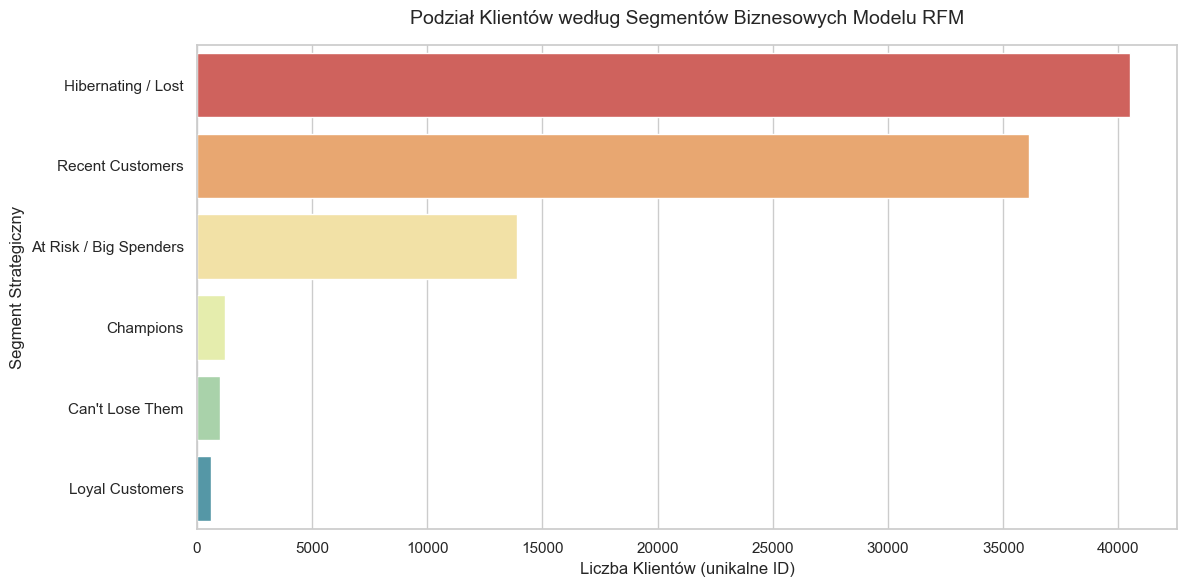

In [12]:
df_rfm = con.execute("""
WITH customer_rfm_raw AS (
    SELECT 
        c.customer_unique_id,
        DATE_PART('day', (SELECT MAX(purchase_time) FROM v_cleaned_orders) - MAX(o.purchase_time)) AS recency_days,
        COUNT(DISTINCT o.order_id) AS frequency,
        ROUND(SUM(i.price), 2) AS monetary_value
    FROM v_cleaned_orders o
    JOIN order_items i ON o.order_id = i.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
rfm_scores AS (
    SELECT *,
        NTILE(5) OVER (ORDER BY recency_days DESC) AS r_score,
        CASE WHEN frequency = 1 THEN 1 ELSE NTILE(4) OVER (ORDER BY frequency) + 1 END AS f_score,
        NTILE(5) OVER (ORDER BY monetary_value) AS m_score
    FROM customer_rfm_raw
)
SELECT *,
    CASE 
        WHEN r_score >= 4 AND f_score >= 4 THEN 'Champions'
        WHEN r_score >= 3 AND f_score >= 2 THEN 'Loyal Customers'
        WHEN r_score >= 4 AND f_score = 1 THEN 'Recent Customers'
        WHEN r_score <= 2 AND f_score >= 3 THEN 'Can''t Lose Them'
        WHEN r_score <= 2 AND f_score <= 2 AND m_score >= 4 THEN 'At Risk / Big Spenders'
        ELSE 'Hibernating / Lost'
    END AS segment
FROM rfm_scores;
""").df()

df_summary = df_rfm.groupby('segment').agg(
    customer_count=('customer_unique_id', 'count')
).reset_index().sort_values(by='customer_count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_summary, x='customer_count', y='segment', palette='Spectral', hue='segment', legend=False)
plt.title('Podział Klientów według Segmentów Biznesowych Modelu RFM', pad=15)
plt.xlabel('Liczba Klientów (unikalne ID)')
plt.ylabel('Segment Strategiczny')
plt.tight_layout()
plt.show()

## 🎯 6. Podsumowanie Biznesowe i Rekomendacje (Executive Summary)

Przeprowadzona analiza eksploracyjna (EDA) oraz zaawansowana segmentacja RFM na danych platformy **Olist** pozwalają na sformułowanie kluczowych wniosków oraz strategicznych rekomendacji dla rozwoju biznesu.

### 📌 1. Główne Wnioski z Analizy Danych (Insights)
* **Stabilny wzrost z wyraźną sezonowością:** Platforma wykazuje stały trend wzrostowy przychodów i wolumenu zamówień w latach 2017–2018. Kluczowym punktem sprzedaży w każdym roku jest **Black Friday** (listopad), generujący gwałtowne piki przychodowe, na które logistyka musi być przygotowana z dużym wyprzedzeniem.
* **Wąskie gardła logistyczne:** Analiza geograficzna ujawniła znaczne dysproporcje w czasie dostaw. Niektóre stany w Brazylii (szczególnie te oddalone od centrum gospodarczego, jak np. północne regiony) charakteryzują się niepokojąco wysokim odsetkiem zamówień opóźnionych w stosunku do daty estymowanej.
* **Logistyka bezpośrednim motorem satysfakcji:** Dane jednoznacznie potwierdzają hipotezę, że opóźnienie dostawy drastycznie obniża oceny konsumenckie. Średnia ocena (`review_score`) dla zamówień dostarczonych na czas jest bliska ideału (ok. 4.2-4.5), podczas gdy zamówienia opóźnione skutkują tąpnięciem satysfakcji i drastycznym wzrostem ocen negatywnych (1-2 gwiazdki).

### 🚀 2. Strategia Działań dla Segmentów RFM
W oparciu o dystrybucję klientów w modelu RFM, rekomenduje się wdrożenie zróżnicowanych działań marketingowo-operacyjnych:

| Segment klientów | Charakterystyka | Rekomendowana Akcja Biznesowa |
| :--- | :--- | :--- |
| **Champions (Czempioni)** | Kupują bardzo często, niedawno i wydają najwięcej. | **Program ambasadorski:** Nagradzaj ich ekskluzywnym, wcześniejszym dostępem do nowych produktów. Nie potrzebują agresywnych rabatów cenowych – doceniają status i jakość obsługi. |
| **Loyal Customers (Lojalni)** | Regularnie powracający klienci o dobrej wartości. | **Programy lojalnościowe:** Oferuj spersonalizowane rekomendacje produktowe (Upselling/Cross-selling) oraz darmową dostawę przy przekroczeniu określonego progu koszyka. |
| **Recent Customers (Nowi)** | Złożyli zamówienie niedawno, ale to ich pierwszy zakup. | **Proces Onboardingu:** Wyślij automatyczną sekwencję powitalną (e-mail) z podziękowaniem, instrukcją korzystania z platformy oraz kuponem zniżkowym na *drugie* zamówienie, aby natychmiast budować nawyk powrotu. |
| **At Risk / Big Spenders (Zagrożeni)** | Dawniej zostawiali duże kwoty, ale dawno nic nie kupili. | **Kampanie Reaktywacyjne (Win-back):** Spersonalizowany kontakt e-mail/SMS typu *'Tęsknimy za Tobą'*. Zaoferuj dedykowany, atrakcyjny rabat na kategorie produktów, które przeglądali lub kupowali w przeszłości. |
| **Hibernating / Lost (Uśpieni)** | Niska częstotliwość, małe kwoty, brak aktywności od dłuższego czasu. | **Automatyzacja niskokosztowa:** Nie inwestuj budżetu w drogie kampanie reklamowe (Paid Ads). Ogranicz się do masowych, zautomatyzowanych newsletterów informujących o wielkich wyprzedażach (np. przed Black Friday). |

---
### 🛠️ Następne Kroki (Future Work)
Dla dalszego rozwoju projektu warto rozważyć wdrożenie modeli uczenia maszynowego (Machine Learning), takich jak **K-Means Clustering** w celu nienadzorowanej, wielowymiarowej segmentacji klientów oraz modeli predykcyjnych do prognozowania rezygnacji klientów (**Churn Prediction**).

## 🎯 6. Podsumowanie Biznesowe i Rekomendacje (Executive Summary)

Przeprowadzona analiza eksploracyjna (EDA) oraz zaawansowana segmentacja RFM na danych platformy **Olist** pozwalają na sformułowanie kluczowych wniosków oraz strategicznych rekomendacji dla rozwoju biznesu.

### 📌 1. Główne Wnioski z Analizy Danych (Insights)
* **Stabilny wzrost z wyraźną sezonowością:** Platforma wykazuje stały trend wzrostowy przychodów i wolumenu zamówień w latach 2017–2018. Kluczowym punktem sprzedaży w każdym roku jest **Black Friday** (listopad), generujący gwałtowne piki przychodowe, na które logistyka musi być przygotowana z dużym wyprzedzeniem.
* **Wąskie gardła logistyczne:** Analiza geograficzna ujawniła znaczne dysproporcje w czasie dostaw. Niektóre stany w Brazylii (szczególnie te oddalone od centrum gospodarczego, jak np. północne regiony) charakteryzują się niepokojąco wysokim odsetkiem zamówień opóźnionych w stosunku do daty estymowanej.
* **Logistyka bezpośrednim motorem satysfakcji:** Dane jednoznacznie potwierdzają hipotezę, że opóźnienie dostawy drastycznie obniża oceny konsumenckie. Średnia ocena (`review_score`) dla zamówień dostarczonych na czas jest bliska ideału (ok. 4.2-4.5), podczas gdy zamówienia opóźnione skutkują tąpnięciem satysfakcji i drastycznym wzrostem ocen negatywnych (1-2 gwiazdki).

### 🚀 2. Strategia Działań dla Segmentów RFM
W oparciu o dystrybucję klientów w modelu RFM, rekomenduje się wdrożenie zróżnicowanych działań marketingowo-operacyjnych:

| Segment klientów | Charakterystyka | Rekomendowana Akcja Biznesowa |
| :--- | :--- | :--- |
| **Champions (Czempioni)** | Kupują bardzo często, niedawno i wydają najwięcej. | **Program ambasadorski:** Nagradzaj ich ekskluzywnym, wcześniejszym dostępem do nowych produktów. Nie potrzebują agresywnych rabatów cenowych – doceniają status i jakość obsługi. |
| **Loyal Customers (Lojalni)** | Regularnie powracający klienci o dobrej wartości. | **Programy lojalnościowe:** Oferuj spersonalizowane rekomendacje produktowe (Upselling/Cross-selling) oraz darmową dostawę przy przekroczeniu określonego progu koszyka. |
| **Recent Customers (Nowi)** | Złożyli zamówienie niedawno, ale to ich pierwszy zakup. | **Proces Onboardingu:** Wyślij automatyczną sekwencję powitalną (e-mail) z podziękowaniem, instrukcją korzystania z platformy oraz kuponem zniżkowym na *drugie* zamówienie, aby natychmiast budować nawyk powrotu. |
| **At Risk / Big Spenders (Zagrożeni)** | Dawniej zostawiali duże kwoty, ale dawno nic nie kupili. | **Kampanie Reaktywacyjne (Win-back):** Spersonalizowany kontakt e-mail/SMS typu *'Tęsknimy za Tobą'*. Zaoferuj dedykowany, atrakcyjny rabat na kategorie produktów, które przeglądali lub kupowali w przeszłości. |
| **Hibernating / Lost (Uśpieni)** | Niska częstotliwość, małe kwoty, brak aktywności od dłuższego czasu. | **Automatyzacja niskokosztowa:** Nie inwestuj budżetu w drogie kampanie reklamowe (Paid Ads). Ogranicz się do masowych, zautomatyzowanych newsletterów informujących o wielkich wyprzedażach (np. przed Black Friday). |

---
### 🛠️ Następne Kroki (Future Work)
Dla dalszego rozwoju projektu warto rozważyć wdrożenie modeli uczenia maszynowego (Machine Learning), takich jak **K-Means Clustering** w celu nienadzorowanej, wielowymiarowej segmentacji klientów oraz modeli predykcyjnych do prognozowania rezygnacji klientów (**Churn Prediction**).